In [105]:
import numpy as np
import tensorflow
from tensorflow import keras

from keras.datasets import mnist
import matplotlib.pyplot as plt

In [106]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

#Normalize
X_train=X_train/255.0
X_test=X_test/255.0

# Flatten: (60000,28,28) → (784,60000)
X_train=X_train.reshape(60000,784).T
X_test=X_test.reshape(10000,784).T



In [107]:
m=10000
Dx=784
Da1=128
Da2=64
c=10



In [108]:
Y_train = np.zeros((y_train.size, c))
Y_train[np.arange(y_train.size), y_train] = 1

Y_test = np.zeros((y_test.size, c))
Y_test[np.arange(y_test.size), y_test] = 1


print("Processed X_train:", X_train.shape)   # (784,60000)
print("Processed Y_train:", y_train.shape)   # (60000,10)

Processed X_train: (784, 60000)
Processed Y_train: (60000,)


In [109]:
W1 = np.random.randn(Dx, Da1) * 0.01
b1 = np.zeros((Da1, 1))

W2 = np.random.randn(Da1, Da2) * 0.01
b2 = np.zeros((Da2, 1))

W3 = np.random.randn(Da2, c) * 0.01
b3 = np.zeros((c, 1))

In [110]:
def relu(z):
    return np.maximum(0,z)

def tanh(z):
    return np.tanh(z)

def sigmoid(z):
    return 1/(1+np.exp(-z))

def softmax(z):
    exps=np.exp(z-np.max(z,axis=0,keepdims=True))
    return exps/np.sum(exps,axis=0,keepdims=True)

In [111]:

def forward_propagation(X):

    z1 = np.dot(W1.T, X) + b1
    a1 = relu(z1)

    z2 = np.dot(W2.T, a1) + b2
    a2 = relu(z2)

    z3 = np.dot(W3.T, a2) + b3
    a3 = softmax(z3)

    return z1, a1, z2, a2, z3, a3

In [112]:
def calculate_loss(Y, Y_hat):

    loss = (-1 / m) * np.sum(Y.T * np.log(Y_hat + 1e-9))
    return loss

In [113]:
def backpropagation(W1,b1,W2,b2,W3,b3,X, Y, z1, a1, z2, a2, z3, a3, lr):


    # Output Layer
    dZ3 = (1 / m) * (a3 - Y.T)
    dW3 = np.dot(a2, dZ3.T)
    db3 = np.sum(dZ3, axis=1, keepdims=True)

    # Hidden Layer 2
    dA2 = np.dot(W3, dZ3)
    dZ2 = dA2 * (z2 > 0)

    dW2 = np.dot(a1, dZ2.T)
    db2 = np.sum(dZ2, axis=1, keepdims=True)

    # Hidden Layer 1
    dA1 = np.dot(W2, dZ2)
    dZ1 = dA1 * (z1 > 0)

    dW1 = np.dot(X, dZ1.T)
    db1 = np.sum(dZ1, axis=1, keepdims=True)

    # Update Parameters
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1

    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

    W3 = W3 - lr * dW3
    b3 = b3 - lr * db3

    return (W1,b1,W2,b2,W3,b3)

Epoch 1/100, Loss = 13.8154
Epoch 2/100, Loss = 13.8142
Epoch 3/100, Loss = 13.8131
Epoch 4/100, Loss = 13.8121
Epoch 5/100, Loss = 13.8112
Epoch 6/100, Loss = 13.8103
Epoch 7/100, Loss = 13.8095
Epoch 8/100, Loss = 13.8088
Epoch 9/100, Loss = 13.8081
Epoch 10/100, Loss = 13.8074
Epoch 11/100, Loss = 13.8068
Epoch 12/100, Loss = 13.8062
Epoch 13/100, Loss = 13.8056
Epoch 14/100, Loss = 13.8049
Epoch 15/100, Loss = 13.8043
Epoch 16/100, Loss = 13.8037
Epoch 17/100, Loss = 13.8031
Epoch 18/100, Loss = 13.8025
Epoch 19/100, Loss = 13.8018
Epoch 20/100, Loss = 13.8012
Epoch 21/100, Loss = 13.8004
Epoch 22/100, Loss = 13.7997
Epoch 23/100, Loss = 13.7988
Epoch 24/100, Loss = 13.7979
Epoch 25/100, Loss = 13.7969
Epoch 26/100, Loss = 13.7959
Epoch 27/100, Loss = 13.7947
Epoch 28/100, Loss = 13.7934
Epoch 29/100, Loss = 13.7919
Epoch 30/100, Loss = 13.7903
Epoch 31/100, Loss = 13.7884
Epoch 32/100, Loss = 13.7863
Epoch 33/100, Loss = 13.7840
Epoch 34/100, Loss = 13.7812
Epoch 35/100, Loss = 13

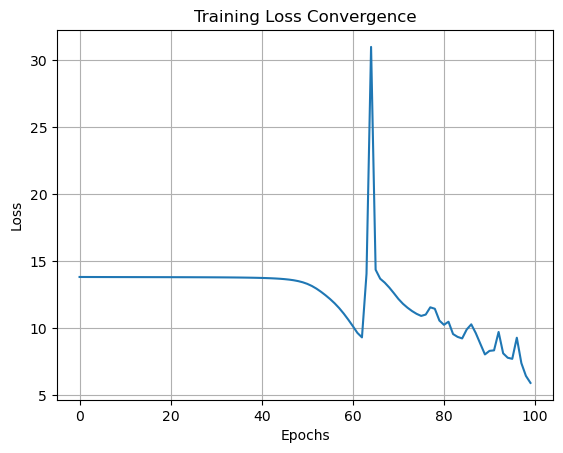

In [114]:

learning_rate = 0.1
epochs = 100
loss_history = []

for epoch in range(epochs):

    z1, a1, z2, a2, z3, a3 = forward_propagation(X_train)

    loss = calculate_loss(Y_train, a3)
    loss_history.append(loss)

    (W1,b1,W2,b2,W3,b3)=backpropagation(W1,b1,W2,b2,W3,b3,
        X_train, Y_train,
        z1, a1, z2, a2, z3, a3,
        learning_rate
    )

    print(f"Epoch {epoch+1}/{epochs}, Loss = {loss:.4f}")




_, _, _, _, _, test_output = forward_propagation(X_test)

predictions = np.argmax(test_output, axis=0)
accuracy = np.mean(predictions == y_test) * 100

print(f"\nTest Accuracy: {accuracy:.2f}%")


# -----------------------------------
# Plot Loss Curve
# -----------------------------------

plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Convergence")
plt.grid(True)
plt.show()